# 📊 Praktikum Data Science - Pertemuan 7

## Pengantar Machine Learning: Regresi Linear

👩‍🎓 Nama : Deviani Solikhah  
🆔 NIM : 240401010137  
🏫 Kelas : IF403  
💻 Program Studi : S1 PJJ Informatika  

---

### 🎯 Tujuan Praktikum

Pada praktikum ini saya mempelajari konsep dasar Machine Learning menggunakan metode Regresi Linear. Kegiatan yang dilakukan meliputi pembuatan dataset sintetis, preprocessing data, pelatihan model Linear Regression, evaluasi menggunakan metrik MAE, RMSE, dan R², serta visualisasi hasil prediksi untuk memahami performa model dalam memprediksi nilai target.

---

📊 Shape Dataset : (300, 4)

📈 Statistik Deskriptif
       pengalaman     edu    gaji
count      300.00  300.00  300.00
mean         9.90    0.89   27.40
std          5.89    0.83   13.41
min          0.10    0.00    1.67
25%          4.78    0.00   16.24
50%         10.23    1.00   27.97
75%         15.14    2.00   38.89
max         19.80    2.00   54.22


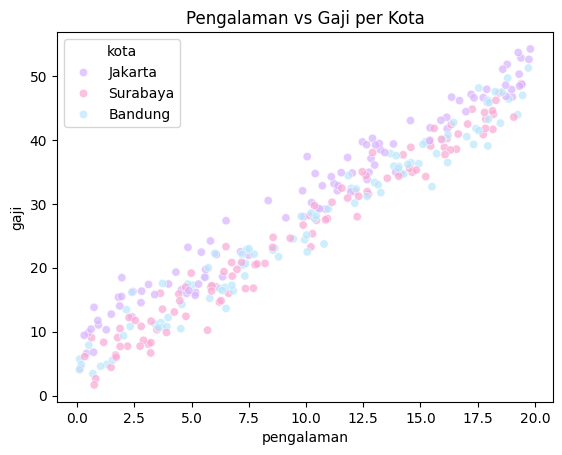

In [1]:
# Generate dan Eksplorasi Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n = 300

pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0,1,2], n)
kota = np.random.choice(
    ['Jakarta','Surabaya','Bandung'],
    n
)

gaji = (
    3.0 +
    2.2 * pengalaman +
    1.5 * edu +
    np.where(kota=='Jakarta',4.0,0) +
    np.random.normal(0,2,n)
)

df = pd.DataFrame({
    'pengalaman': pengalaman,
    'edu': edu,
    'kota': kota,
    'gaji': gaji
})

print("📊 Shape Dataset :", df.shape)

print("\n📈 Statistik Deskriptif")
print(df.describe().round(2))

sns.scatterplot(
    data=df,
    x='pengalaman',
    y='gaji',
    hue='kota',
    palette=['#D8B4FE','#F9A8D4','#BAE6FD'],
    alpha=0.7
)

plt.title("Pengalaman vs Gaji per Kota")
plt.show() 

In [3]:
# Preprocessing Data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.get_dummies(
    df,
    columns=['kota'],
    drop_first=True,
    dtype=int
)

print("📋 Kolom Setelah Encoding")
print(df.columns.tolist())

X = df.drop('gaji', axis=1)
y = df['gaji']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"\n📊 Train : {X_train.shape[0]} baris")
print(f"📊 Test  : {X_test.shape[0]} baris")

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test) 

📋 Kolom Setelah Encoding
['pengalaman', 'edu', 'gaji', 'kota_Jakarta', 'kota_Surabaya']

📊 Train : 240 baris
📊 Test  : 60 baris


In [4]:
# Melatih Model Regresi Linear

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_s,
    y_train
)

print(f"📌 β₀ (Intercept) : {model.intercept_:.3f}")

coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_.round(3)
}).sort_values(
    by='Koefisien',
    ascending=False
)

print("\n📈 Koefisien Model")
print(coef_df.to_string(index=False)) 

📌 β₀ (Intercept) : 27.514

📈 Koefisien Model
        Fitur  Koefisien
   pengalaman     13.042
 kota_Jakarta      1.837
          edu      1.188
kota_Surabaya     -0.292


In [5]:
# Evaluasi Model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("📊 Metrik Evaluasi")

print(f"\n📌 MAE  = {mae:.3f}")
print(f"📌 RMSE = {rmse:.3f}")
print(f"📌 R²   = {r2:.4f}")

print(
    f"\n📈 Variasi data yang dijelaskan model = {r2*100:.1f}%"
)

print(
    f"📉 Selisih RMSE - MAE = {rmse-mae:.3f}"
) 

📊 Metrik Evaluasi

📌 MAE  = 1.649
📌 RMSE = 2.123
📌 R²   = 0.9740

📈 Variasi data yang dijelaskan model = 97.4%
📉 Selisih RMSE - MAE = 0.474


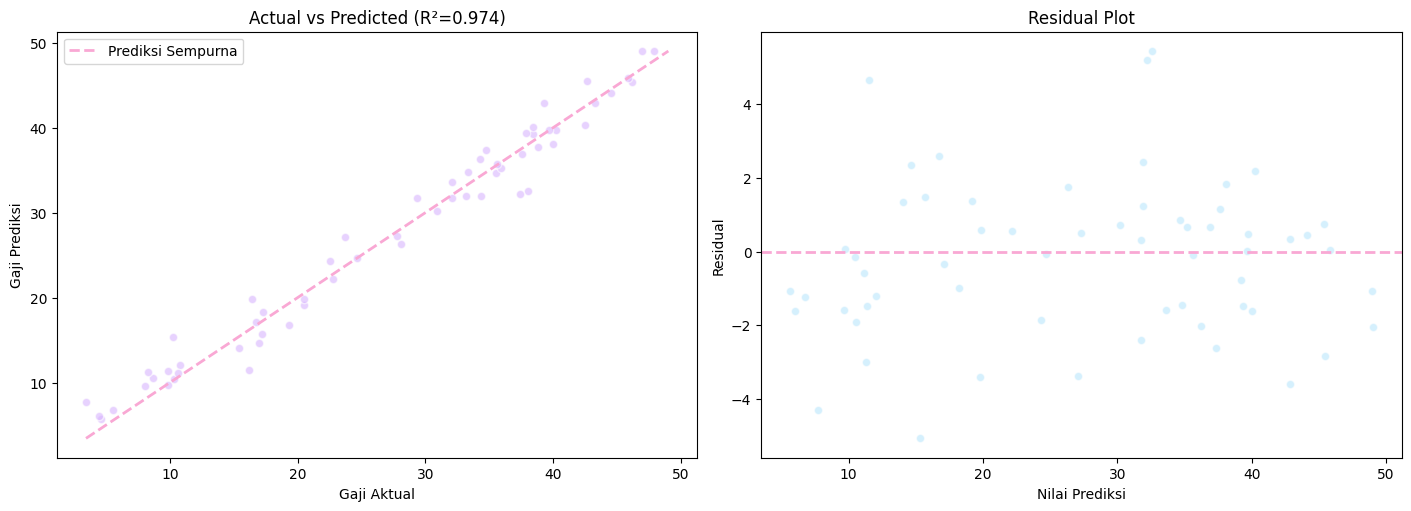

In [6]:
# Visualisasi Hasil Prediksi

fig, axes = plt.subplots(
    1, 2,
    figsize=(14,5),
    constrained_layout=True
)

# Actual vs Predicted
axes[0].scatter(
    y_test,
    y_pred,
    alpha=0.6,
    color='#D8B4FE',
    edgecolors='white'
)

lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

axes[0].plot(
    lims,
    lims,
    '--',
    color='#F9A8D4',
    linewidth=2,
    label='Prediksi Sempurna'
)

axes[0].set_title(
    f'Actual vs Predicted (R²={r2:.3f})'
)
axes[0].set_xlabel('Gaji Aktual')
axes[0].set_ylabel('Gaji Prediksi')
axes[0].legend()

# Residual Plot
residuals = y_test - y_pred

axes[1].scatter(
    y_pred,
    residuals,
    alpha=0.6,
    color='#BAE6FD',
    edgecolors='white'
)

axes[1].axhline(
    0,
    color='#F9A8D4',
    linestyle='--',
    linewidth=2
)

axes[1].set_title('Residual Plot')
axes[1].set_xlabel('Nilai Prediksi')
axes[1].set_ylabel('Residual')

plt.show() 

### 🔎 Analisis (What? So What? Now What?)

**What?**
Grafik Actual vs Predicted menunjukkan hubungan antara nilai aktual dan nilai prediksi model. Residual Plot menunjukkan selisih antara nilai aktual dan nilai prediksi.

**So What?**
Sebagian besar titik berada dekat dengan garis prediksi sempurna, yang menunjukkan bahwa model mampu melakukan prediksi dengan cukup baik. Residual yang tersebar di sekitar garis nol menandakan tidak terdapat pola kesalahan yang signifikan.

**Now What?**
Model dapat digunakan sebagai dasar prediksi gaji, namun performanya masih dapat ditingkatkan dengan menambahkan fitur lain yang lebih relevan atau menggunakan model regresi yang lebih kompleks.

## 📝 Kesimpulan

Pada praktikum ini saya mempelajari konsep dasar Machine Learning menggunakan metode Regresi Linear. Tahapan yang dilakukan meliputi pembuatan dataset sintetis, preprocessing data, pelatihan model, evaluasi menggunakan metrik MAE, RMSE, dan R², serta visualisasi hasil prediksi.

Dari hasil praktikum diperoleh bahwa Regresi Linear mampu memodelkan hubungan antara pengalaman kerja, pendidikan, dan lokasi kerja terhadap gaji dengan cukup baik. Selain itu saya memahami pentingnya proses evaluasi model untuk mengukur kualitas prediksi sebelum model digunakan pada kasus nyata.